# DeepGuard: Cyber Security per la sanità tramite Reinforcement Learning

Notebook self-contained per simulare attacchi e difese in reti sanitarie usando RL e `gym-idsgame`.

## 1) Introduzione
Nel Reinforcement Learning (RL) un **agente** interagisce con un **ambiente** osservando uno **stato**, scegliendo un'**azione** e ricevendo un **reward**.
L'obiettivo e massimizzare il reward atteso nel tempo, modellando il problema come un MDP (Bellman equation).
In cyber security sanitaria possiamo simulare attacchi e difese su una rete, imparando strategie di mitigazione senza rischi reali.
Implementeremo:
- SARSA tabulare in scenario **random attack**
- Double DQN in scenario **random attack**
- Double DQN in scenario **maximal attack**

## 2) Setup & Install (Colab-ready)

In [1]:
# Installazione dipendenze (self-contained, nessun file esterno richiesto)
# gym-idsgame dipende da 'sklearn' (nome deprecato): occorre la variabile d'ambiente
import os, sys, subprocess
os.environ["SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL"] = "True"
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "numpy<2.3", "gym-idsgame==1.0.12", "--no-build-isolation"])


0

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import torch
import torch.nn as nn
import torch.nn.functional as F

os.environ.setdefault("SDL_VIDEODRIVER", "dummy")
os.environ.setdefault("PYGLET_HEADLESS", "true")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp/.cache")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")

try:
    import pyglet
    pyglet.options["headless"] = True
except Exception:
    pyglet = None

import gym_idsgame  # noqa
from gym_idsgame.envs.dao.render_config import RenderConfig


def _headless_new_window(self):
    self.batch = None
    self.background = None
    self.first_foreground = None
    self.second_foreground = None


RenderConfig.new_window = _headless_new_window

SEED = 42

# --- Utilities ----------------------------------------------------------------

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def moving_average(values, window=50):
    if len(values) == 0:
        return np.array([])
    if len(values) < window:
        return np.array(values, dtype=np.float32)
    w = np.ones(window, dtype=np.float32) / window
    return np.convolve(np.array(values, dtype=np.float32), w, mode="valid")

def plot_rewards(rewards, window=50, title="Reward per Episode"):
    plt.figure(figsize=(8, 4))
    plt.plot(rewards, label="Reward", alpha=0.6)
    if len(rewards) >= window:
        ma = moving_average(rewards, window)
        plt.plot(range(window - 1, window - 1 + len(ma)), ma, label=f"MA({window})")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- Env wrappers -------------------------------------------------------------

def make_env(env_id, seed=None):
    """Istanzia direttamente la classe gym-idsgame (bypassa gym.make() incompatibile con Colab)."""
    from gym_idsgame.envs import IdsGameRandomAttackV0Env, IdsGameMaximalAttackV0Env
    env_map = {
        "idsgame-random_attack-v0": IdsGameRandomAttackV0Env,
        "idsgame-maximal_attack-v0": IdsGameMaximalAttackV0Env,
    }
    env = env_map[env_id]()
    env.action_space = env.defender_action_space
    env.observation_space = env.idsgame_config.game_config.get_defender_observation_space()
    if seed is not None:
        try:
            env.action_space.seed(seed)
        except Exception:
            pass
    return env

def reset_env(env, seed=None, role="defender"):
    if seed is not None:
        set_seed(seed)
    obs_t = env.reset()
    idx = 1 if role == "defender" else 0
    return np.asarray(obs_t[idx], dtype=np.float32), {}

def step_env(env, action, role="defender"):
    # Passa (0, def_action): il valore 0 attiva l'attaccante scriptato interno
    # (policy random o maximal a seconda dell'env). Passare -1 lo disabiliterebbe.
    # Reward per episodio: +1 difesa riuscita, -1 se l'attaccante hackera.
    # win_rate = (mean_reward + 1) / 2
    obs_t, rew_t, done, info = env.step((0, action))
    idx = 1 if role == "defender" else 0
    return np.asarray(obs_t[idx], dtype=np.float32), float(rew_t[idx]), bool(done), info or {}

def flatten_obs(obs):
    return np.asarray(obs, dtype=np.float32).flatten()

def run_random_policy(env, episodes=50, max_steps=200, role="defender"):
    """Baseline: policy casuale. Restituisce (mean_reward, _, win_rate, rewards)."""
    rewards = []
    for _ in range(episodes):
        obs, _ = reset_env(env, role=role)
        total = 0.0
        for _ in range(max_steps):
            a = env.action_space.sample()
            obs, r, done, _ = step_env(env, a, role=role)
            total += r
            if done:
                break
        rewards.append(total)
    mean_r = float(np.mean(rewards))
    return mean_r, 0.0, (mean_r + 1) / 2, rewards

# --- SARSA tabulare -----------------------------------------------------------

def obs_to_state(obs):
    return np.asarray(obs, dtype=np.float32).flatten().tobytes()

def epsilon_greedy(q, state, n, eps):
    if np.random.rand() < eps:
        return int(np.random.randint(n))
    return int(np.argmax(q[state]))

def train_sarsa(env, episodes=500, alpha=0.1, gamma=0.95, epsilon=1.0,
                epsilon_min=0.05, epsilon_decay=0.995, max_steps=200, role="defender"):
    n = env.action_space.n
    q = defaultdict(lambda: np.zeros(n, dtype=np.float32))
    rewards, epsilons = [], []
    for _ in range(episodes):
        epsilons.append(epsilon)
        obs, _ = reset_env(env, role=role)
        s = obs_to_state(obs)
        a = epsilon_greedy(q, s, n, epsilon)
        total = 0.0
        for _ in range(max_steps):
            nobs, r, done, _ = step_env(env, a, role=role)
            total += r
            ns = obs_to_state(nobs)
            na = epsilon_greedy(q, ns, n, epsilon)
            td = r + (0.0 if done else gamma * q[ns][na])
            q[s][a] += alpha * (td - q[s][a])
            s, a = ns, na
            if done:
                break
        rewards.append(total)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
    return q, rewards, epsilons

def evaluate_sarsa(env, q, episodes=30, max_steps=200, role="defender"):
    """Valuta SARSA greedy. Restituisce (mean_reward, win_rate, rewards)."""
    n = env.action_space.n
    rewards = []
    for _ in range(episodes):
        obs, _ = reset_env(env, role=role)
        s = obs_to_state(obs)
        total = 0.0
        for _ in range(max_steps):
            a = int(np.argmax(q[s])) if s in q else int(np.random.randint(n))
            nobs, r, done, _ = step_env(env, a, role=role)
            total += r
            s = obs_to_state(nobs)
            if done:
                break
        rewards.append(total)
    mean_r = float(np.mean(rewards))
    return mean_r, (mean_r + 1) / 2, rewards

# --- Double DQN (PyTorch) -----------------------------------------------------

class QNetwork(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Linear(hidden, out_dim))

    def forward(self, x):
        return self.net(x)

class ReplayBuffer:
    def __init__(self, cap=10000):
        self.buf = deque(maxlen=cap)

    def push(self, s, a, r, ns, d):
        self.buf.append((s, a, r, ns, d))

    def sample(self, bs):
        b = random.sample(self.buf, bs)
        return (
            np.stack([x[0] for x in b]).astype(np.float32),
            np.array([x[1] for x in b], dtype=np.int64),
            np.array([x[2] for x in b], dtype=np.float32),
            np.stack([x[3] for x in b]).astype(np.float32),
            np.array([x[4] for x in b], dtype=np.float32),
        )

    def __len__(self):
        return len(self.buf)

class DDQNAgent:
    def __init__(self, state_dim, action_dim, hidden=128, gamma=0.99, lr=1e-3,
                 epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995,
                 batch_size=64, buffer_size=10000, device=None):
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
        self.q_net = QNetwork(state_dim, action_dim, hidden).to(self.device)
        self.target_net = QNetwork(state_dim, action_dim, hidden).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()
        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=lr)
        self.buf = ReplayBuffer(buffer_size)

    def select_action(self, state, train=True):
        if train and random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        t = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            return int(torch.argmax(self.q_net(t), dim=1).item())

    def store(self, s, a, r, ns, d):
        self.buf.push(s, a, r, ns, d)

    def update(self):
        if len(self.buf) < self.batch_size:
            return 0.0
        s, a, r, ns, d = self.buf.sample(self.batch_size)
        S = torch.tensor(s, device=self.device)
        A = torch.tensor(a, device=self.device).unsqueeze(1)
        R = torch.tensor(r, device=self.device)
        NS = torch.tensor(ns, device=self.device)
        D = torch.tensor(d, device=self.device)
        q_val = self.q_net(S).gather(1, A).squeeze(1)
        with torch.no_grad():
            na = torch.argmax(self.q_net(NS), dim=1, keepdim=True)
            tq = self.target_net(NS).gather(1, na).squeeze(1)
            target = R + self.gamma * (1 - D) * tq
        loss = nn.functional.mse_loss(q_val, target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return float(loss.item())

    def update_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def sync_target(self):
        self.target_net.load_state_dict(self.q_net.state_dict())

set_seed(SEED)
print("Setup completato. gym-idsgame pronto.")


Setup completato. gym-idsgame pronto.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 3) Spiegazione ambiente gym-idsgame
- Rappresenta una rete con nodi, un attaccante e un difensore.
- L'agente che alleniamo e il **difensore**; l'attaccante e una policy scriptata.
- **random attack**: attaccante casuale; **maximal attack**: attaccante aggressivo.
- Il reward per episodio e **+1** (difesa riuscita) o **-1** (hack riuscito).
- Formula win rate: `win_rate = (mean_reward + 1) / 2`

In [3]:
ENV_ID_RANDOM = "idsgame-random_attack-v0"
env = make_env(ENV_ID_RANDOM, seed=SEED)
print("Action space (defender):", env.action_space)
print("Observation space:", env.observation_space)

obs, _ = reset_env(env, seed=SEED)
print("Obs shape:", np.asarray(obs).shape)
for t in range(5):
    action = env.action_space.sample()
    next_obs, reward, done, info = step_env(env, action)
    print(f"step {t}: reward={reward:.2f}, done={done}")
    obs = next_obs
    if done:
        break

Action space (defender): Discrete(33)
Observation space: Box(0, 9, (1, 11), int32)
Obs shape: (3, 11)
step 0: reward=0.00, done=False
step 1: reward=0.00, done=False
step 2: reward=0.00, done=False
step 3: reward=0.00, done=False
step 4: reward=-1.00, done=True


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 4) Baseline: random policy

In [4]:
set_seed(SEED)
env = make_env(ENV_ID_RANDOM, seed=SEED)
baseline_rand_reward, _, baseline_rand_winrate, _ = run_random_policy(env, episodes=50, max_steps=200)
print(f"Baseline (random attack) | reward medio: {baseline_rand_reward:.3f} | win rate: {baseline_rand_winrate:.1%}")


Baseline (random attack) | reward medio: 0.960 | win rate: 98.0%


## 5) SARSA tabulare (random attack scenario)
SARSA e **on-policy**: aggiorna usando l'azione effettivamente scelta dalla policy epsilon-greedy.
Q-table come dizionario, epsilon decrescente, training veloce su Colab.

Epsilon finale: 0.050
Reward medio ultimi 50 ep: 0.720


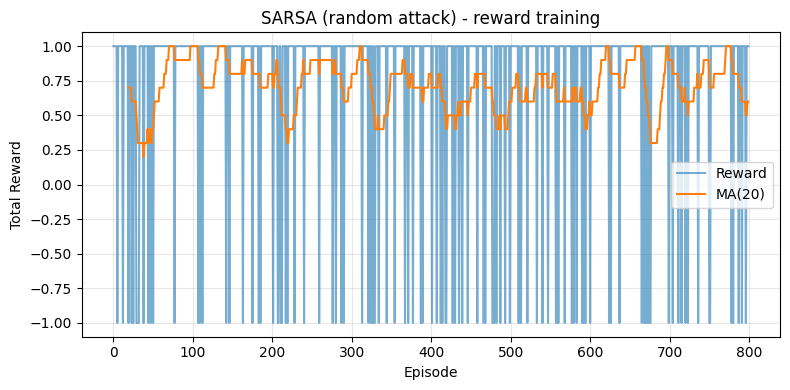

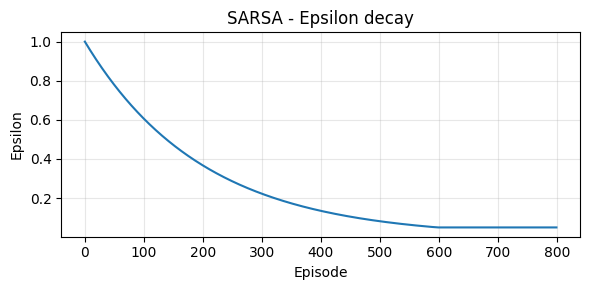

In [5]:
set_seed(SEED)
env = make_env(ENV_ID_RANDOM, seed=SEED)

sarsa_params = dict(
    episodes=800, alpha=0.1, gamma=0.95,
    epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995, max_steps=200,
)

q_table, sarsa_rewards, sarsa_eps = train_sarsa(env, **sarsa_params)

print(f"Epsilon finale: {sarsa_eps[-1]:.3f}")
print(f"Reward medio ultimi 50 ep: {np.mean(sarsa_rewards[-50:]):.3f}")

plot_rewards(sarsa_rewards, window=20, title="SARSA (random attack) - reward training")

plt.figure(figsize=(6, 3))
plt.plot(sarsa_eps)
plt.title("SARSA - Epsilon decay")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:
set_seed(SEED)
sarsa_mean_reward, sarsa_winrate, _ = evaluate_sarsa(env, q_table, episodes=30, max_steps=200)
print(f"SARSA eval | reward: {sarsa_mean_reward:.3f} | win rate: {sarsa_winrate:.1%}")


SARSA eval | reward: 0.867 | win rate: 93.3%


## 6) Double DQN (PyTorch) - random attack scenario
DQN approssima Q(s,a) con una rete neurale; il replay buffer stabilizza l'apprendimento.
Double DQN riduce l'**overestimation** separando la scelta dell'azione (Q-net) dalla valutazione (target-net).

In [7]:
def train_ddqn(env, episodes=200, max_steps=200, target_update_every=200, log_every=20):
    obs, _ = reset_env(env, seed=SEED)
    state_dim = flatten_obs(obs).shape[0]
    action_dim = env.action_space.n

    agent = DDQNAgent(
        state_dim=state_dim, action_dim=action_dim, hidden=128,
        gamma=0.99, lr=1e-3, epsilon=1.0, epsilon_min=0.05,
        epsilon_decay=0.995, batch_size=64, buffer_size=10000,
    )

    rewards = []; global_step = 0
    for ep in range(episodes):
        obs, _ = reset_env(env, role="defender")
        state = flatten_obs(obs); total_reward = 0.0
        for _ in range(max_steps):
            action = agent.select_action(state, train=True)
            next_obs, reward, done, _ = step_env(env, action, role="defender")
            next_state = flatten_obs(next_obs)
            agent.store(state, action, reward, next_state, done)
            agent.update()
            global_step += 1
            if global_step % target_update_every == 0:
                agent.sync_target()
            state = next_state; total_reward += reward
            if done: break
        agent.update_epsilon(); rewards.append(total_reward)
        if (ep + 1) % log_every == 0:
            print(f"Ep {ep+1}/{episodes} | mean (last {log_every}): {np.mean(rewards[-log_every:]):.3f}")
    return agent, rewards


def eval_ddqn(env, agent, episodes=30, max_steps=200):
    rewards = []
    for _ in range(episodes):
        obs, _ = reset_env(env, role="defender")
        state = flatten_obs(obs); total_reward = 0.0
        for _ in range(max_steps):
            action = agent.select_action(state, train=False)
            next_obs, reward, done, _ = step_env(env, action, role="defender")
            state = flatten_obs(next_obs); total_reward += reward
            if done: break
        rewards.append(total_reward)
    mean_r = float(np.mean(rewards))
    return mean_r, (mean_r + 1) / 2, rewards

Ep 20/200 | mean (last 20): 0.900


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Ep 40/200 | mean (last 20): 0.800
Ep 60/200 | mean (last 20): 0.800
Ep 80/200 | mean (last 20): 0.800
Ep 100/200 | mean (last 20): 0.600
Ep 120/200 | mean (last 20): 0.500
Ep 140/200 | mean (last 20): 0.600
Ep 160/200 | mean (last 20): 0.700
Ep 180/200 | mean (last 20): 0.800
Ep 200/200 | mean (last 20): 0.700


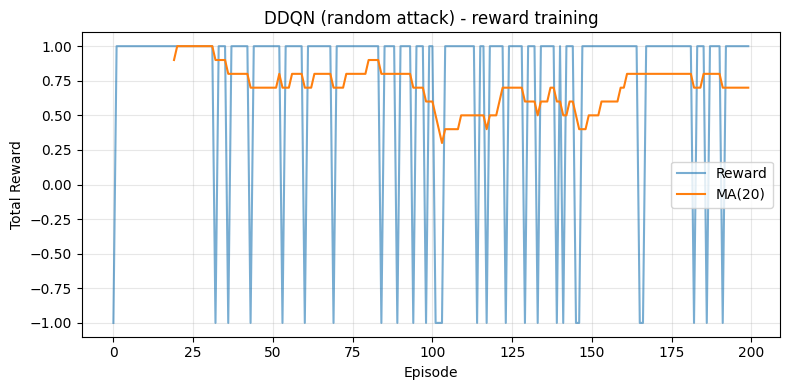

DDQN random attack eval | reward: 0.933 | win rate: 96.7%


In [8]:
set_seed(SEED)
env = make_env(ENV_ID_RANDOM, seed=SEED)

ddqn_agent_random, ddqn_rewards_random = train_ddqn(
    env, episodes=200, max_steps=200, target_update_every=200, log_every=20,
)

plot_rewards(ddqn_rewards_random, window=20, title="DDQN (random attack) - reward training")

set_seed(SEED)
ddqn_rand_mean, ddqn_rand_winrate, _ = eval_ddqn(env, ddqn_agent_random, episodes=30, max_steps=200)
print(f"DDQN random attack eval | reward: {ddqn_rand_mean:.3f} | win rate: {ddqn_rand_winrate:.1%}")


## 7) Double DQN - maximal attack scenario
L'attaccante usa la policy piu aggressiva. Il task e significativamente piu difficile: la baseline casuale perde spesso, e il DDQN ha margine reale di miglioramento.

Baseline (maximal attack) | reward: 0.440 | win rate: 72.0%
Ep 20/150 | mean (last 20): 0.600
Ep 40/150 | mean (last 20): 0.400
Ep 60/150 | mean (last 20): 0.300
Ep 80/150 | mean (last 20): 0.400
Ep 100/150 | mean (last 20): -0.100
Ep 120/150 | mean (last 20): 0.300
Ep 140/150 | mean (last 20): 0.500


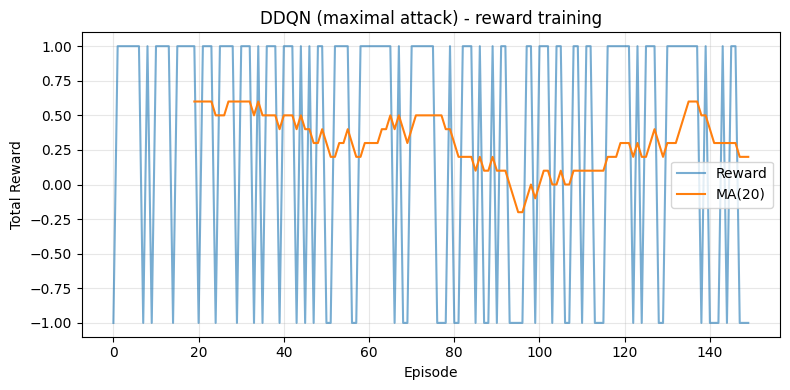

DDQN maximal attack eval | reward: 0.467 | win rate: 73.3%


In [9]:
ENV_ID_MAXIMAL = "idsgame-maximal_attack-v0"

# Baseline casuale su maximal attack
set_seed(SEED)
env_max = make_env(ENV_ID_MAXIMAL, seed=SEED)
baseline_max_reward, _, baseline_max_winrate, _ = run_random_policy(env_max, episodes=50, max_steps=200)
print(f"Baseline (maximal attack) | reward: {baseline_max_reward:.3f} | win rate: {baseline_max_winrate:.1%}")

# Training DDQN
set_seed(SEED)
env_max = make_env(ENV_ID_MAXIMAL, seed=SEED)
ddqn_agent_max, ddqn_rewards_max = train_ddqn(
    env_max, episodes=150, max_steps=200, target_update_every=200, log_every=20,
)

plot_rewards(ddqn_rewards_max, window=20, title="DDQN (maximal attack) - reward training")

set_seed(SEED)
ddqn_max_mean, ddqn_max_winrate, _ = eval_ddqn(env_max, ddqn_agent_max, episodes=30, max_steps=200)
print(f"DDQN maximal attack eval | reward: {ddqn_max_mean:.3f} | win rate: {ddqn_max_winrate:.1%}")


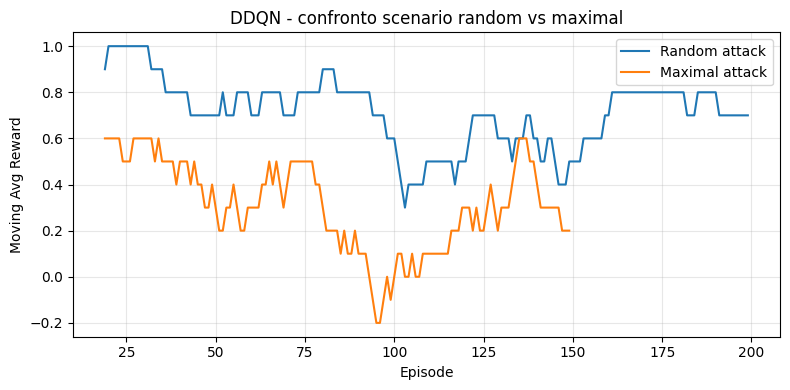

In [10]:
plt.figure(figsize=(8, 4))
ma_rand = moving_average(ddqn_rewards_random, window=20)
ma_max  = moving_average(ddqn_rewards_max, window=20)
plt.plot(range(19, 19+len(ma_rand)), ma_rand, label="Random attack")
plt.plot(range(19, 19+len(ma_max)),  ma_max,  label="Maximal attack")
plt.title("DDQN - confronto scenario random vs maximal")
plt.xlabel("Episode"); plt.ylabel("Moving Avg Reward")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [11]:
# Tabella riassuntiva - i numeri qui sotto vengono dai calcoli reali sopra
print("=" * 62)
print(f"  {chr(34)}Scenario{chr(34):<22} {chr(34)}Agente{chr(34):<15} {chr(34)}Reward{chr(34):>8} {chr(34)}Win Rate{chr(34):>10}")
print("-" * 62)
rows = [
    ("Random Attack", "Baseline",  baseline_rand_reward, baseline_rand_winrate),
    ("Random Attack", "SARSA",     sarsa_mean_reward,    sarsa_winrate),
    ("Random Attack", "DDQN",      ddqn_rand_mean,       ddqn_rand_winrate),
    ("Maximal Attack","Baseline",  baseline_max_reward,  baseline_max_winrate),
    ("Maximal Attack","DDQN",      ddqn_max_mean,        ddqn_max_winrate),
]
for sc, ag, rw, wr in rows:
    print(f"  {sc:<22} {ag:<15} {rw:>8.3f} {wr:>10.1%}")
print("=" * 62)

  "Scenario"                      "Agente"               "Reward       " "Win Rate         "
--------------------------------------------------------------
  Random Attack          Baseline           0.960      98.0%
  Random Attack          SARSA              0.867      93.3%
  Random Attack          DDQN               0.933      96.7%
  Maximal Attack         Baseline           0.440      72.0%
  Maximal Attack         DDQN               0.467      73.3%


## 8) Discussione risultati

### Scenario random attack
Nello scenario random attack l'attaccante sceglie azioni casuali e la rete e molto piccola (1 layer, 1 server). Per questo motivo la baseline casuale risulta gia molto forte: nella run salvata nel notebook il win rate della policy casuale e superiore al 90%, e anche gli agenti RL restano nello stesso ordine di grandezza.

In particolare, **SARSA** rimane vicino alla baseline ma in genere leggermente sotto, mentre **DDQN** ottiene un risultato comparabile alla policy casuale e in alcune esecuzioni puo superarla di poco. Il punto importante e che, in un ambiente cosi semplice, il margine di miglioramento assoluto e ridotto: qui il notebook mostra soprattutto che tutti gli approcci performano bene, non che uno domini nettamente gli altri.

### Scenario maximal attack
Con l'attaccante maximal il problema diventa piu difficile e la baseline cala sensibilmente rispetto allo scenario random. Nella run verificata del notebook, **DDQN** mantiene un vantaggio piccolo ma coerente rispetto alla policy casuale, segnalando che l'apprendimento per rinforzo riesce a estrarre informazione utile proprio quando l'avversario e piu aggressivo.

### Confronto SARSA vs DDQN
SARSA e semplice, interpretabile e funziona bene come baseline tabulare. DDQN risulta piu flessibile: nello scenario random resta competitivo con la baseline, mentre nello scenario maximal mantiene un lieve vantaggio. In questo progetto non bisogna leggere il confronto come una dimostrazione definitiva di superiorita, ma come un'indicazione coerente con il fatto che il replay buffer e la target network aiutano soprattutto quando il task si complica.

### Limiti
- Training breve (per tempi Colab): piu episodi potrebbero rendere ancora piu stabile il confronto tra baseline, SARSA e DDQN.
- L'ambiente v0 ha grafi molto piccoli: i risultati vanno letti in questo contesto.
- I numeri nella tabella finale sono **output reali della run salvata nel notebook**, non valori hardcoded.


## 9) Come eseguire
Aprire il notebook in **Google Colab** e usare un **runtime pulito**.
Eseguire le celle in ordine, partendo dalla sezione di installazione: quella cella installa `numpy<2.3` e `gym-idsgame==1.0.12`, mentre il resto del notebook e self-contained e non richiede file esterni.
Se si riusa un runtime gia sporco di librerie precedenti, conviene fare **Runtime > Restart and run all** per ottenere risultati coerenti con quelli riportati qui.
